# Proyecto TFT Kedro - Análisis Completo CRISP-DM
**Machine Learning Supervisado para Análisis de Rendimiento en Teamfight Tactics**

---

## Resumen Ejecutivo

Este notebook presenta un análisis completo de datos de Teamfight Tactics (TFT) aplicando la metodología CRISP-DM, con enfoque en modelos de Machine Learning supervisado para predecir el rendimiento de jugadores en diferentes rangos competitivos.

### Objetivos
- **Análisis de rendimiento** entre rangos Challenger, Grandmaster y Platinum
- **Predicción de clasificación** de jugadores mediante modelos de clasificación
- **Predicción de Ranked** mediante modelos de regresión
- **Identificación de variables críticas** que influyen en el desempeño

### Metodología
Siguiendo el proceso CRISP-DM:
1. **Business Understanding**: Contexto y objetivos de negocio
2. **Data Understanding**: Exploración exploratoria de datos (EDA)
3. **Data Preparation**: Feature engineering y preparación
4. **Modeling**: Implementación de modelos supervisados (este notebook)
5. **Evaluation**: Evaluación y selección de mejores modelos
6. **Deployment**: Conclusiones e insights aplicables


---

# FASE 1: BUSINESS UNDERSTANDING

## Contexto del Negocio

Teamfight Tactics (TFT) es un videojuego estratégico basado en rondas donde los jugadores compiten construyendo equipos de campeones. En los niveles competitivos más altos (Challenger, Grandmaster y Platinum), las partidas son especialmente relevantes por representar el rendimiento de los mejores jugadores.

### Problema de Negocio

Actualmente no está claro qué elementos del juego tienen mayor impacto en los resultados dentro de las partidas. Esto dificulta:
- Diseñar estrategias de juego más efectivas
- Proporcionar insights a jugadores para mejorar
- Ayudar a desarrolladores a balancear mecánicas entre rangos

### Objetivos del Negocio

1. **Identificar variables clave** que impactan el desempeño de jugadores
2. **Comparar patrones de juego** entre rangos competitivos
3. **Generar insights aplicables** mediante modelos predictivos

### Criterios de Éxito

- Lograr modelos con accuracy > 70% para clasificación
- Identificar al menos 3 variables críticas
- Mostrar diferencias claras entre rangos


---

# FASE 2: DATA UNDERSTANDING

## Carga y Exploración Inicial


In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    classification_report
)
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor
)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")



✅ Librerías importadas correctamente


### Descripción del Dataset

El dataset contiene datos de partidas de TFT de tres rangos competitivos:
- **Challenger**: Rango más alto
- **Grandmaster**: Rango medio-alto  
- **Platinum**: Rango medio

Cargamos datos ya procesados con features de la fase de Data Preparation.


In [ ]:
# Cargar datos con features (robusto: usa parquet si existe, sino concatena CSVs)
from pathlib import Path
feature_dir = Path('../data/04_feature')
parquet_path = feature_dir / 'tft_combined_features.parquet'

if parquet_path.exists():
    print(f"🔎 Parquet encontrado: {parquet_path}")
    df = pd.read_parquet(parquet_path)
else:
    print(f"⚠️ Parquet no encontrado en {parquet_path}. Buscando CSVs en {feature_dir}...")
    csv_files = sorted(feature_dir.glob('*.csv'))
    if not csv_files:
        # Intentar carpeta alternativa relativa desde el notebook
        alt_dir = Path('./data/04_feature')
        csv_files = sorted(alt_dir.glob('*.csv'))
        if csv_files:
            feature_dir = alt_dir
    if not csv_files:
        raise FileNotFoundError(f"No se encontró 'tft_combined_features.parquet' ni archivos CSV en {feature_dir.resolve()}")
    print(f"🔎 Archivos CSV encontrados: {[f.name for f in csv_files]}")
    dfs = [pd.read_csv(f) for f in csv_files]
    df = pd.concat(dfs, ignore_index=True)
    # Guardar parquet combinado para la próxima vez (opcional)
    try:
        df.to_parquet(parquet_path, index=False)
        print(f"✅ Parquet combinado guardado en: {parquet_path}")
    except Exception as e:
        print(f"⚠️ No se pudo guardar parquet: {e}")

print(f"📊 Dataset cargado: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")
if 'rank' in df.columns:
    print(f"\nDistribución por rango:")
    print(df['rank'].value_counts())
else:
    print("\n⚠️ 'rank' no está presente en el dataset. Columnas disponibles:")
    print(df.columns.tolist())


🔎 Parquet encontrado: ..\data\04_feature\tft_combined_features.parquet
📊 Dataset cargado: (239941, 17)
Columnas: ['gameId', 'gameDuration', 'level', 'lastRound', 'Ranked', 'ingameDuration', 'combination', 'champion', 'gameDuration_min', 'gameDuration_hours', 'performance_score', 'efficiency_ratio', 'is_long_game', 'is_high_level', 'rank_normalized', 'level_duration_interaction', 'rank']

Distribución por rango:
rank
Challenger     79999
Grandmaster    79994
Platinum       79948
Name: count, dtype: int64


---

# FASE 3: DATA PREPARATION

## Preparación de Datos para Machine Learning

Separamos los datos en features (X) y targets (y) para clasificación y regresión.

### Justificación de Variables

Para **clasificación** (predecir rango del jugador):
- Target: `rank` (Challenger, Grandmaster, Platinum)
- Features: variables numéricas que no sean el target

Para **regresión** (predecir Ranked):
- Target: `Ranked` (posición final 1-8)
- Features: variables numéricas que no sean el target

Eliminamos columnas categóricas no numéricas y utilizamos imputación por mediana para manejar valores faltantes.


In [ ]:
# Preparar features numéricas para ML
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['rank', 'Ranked']
feature_columns = [col for col in numeric_features if col not in exclude_cols]

print(f"Features identificadas: {feature_columns}")

# Preparar datos para clasificación (predecir rango)
X_classification = df[feature_columns].fillna(df[feature_columns].median())
y_classification = df['rank']

# Preparar datos para regresión (predecir Ranked)
X_regression = df[feature_columns].fillna(df[feature_columns].median())
y_regression = df['Ranked']

print(f"\n📊 Clasificación:")
print(f"  Features: {X_classification.shape}")
print(f"  Target: {y_classification.value_counts().to_dict()}")

print(f"\n📈 Regresión:")
print(f"  Features: {X_regression.shape}")
print(f"  Target: rango {y_regression.min()}-{y_regression.max()}, media {y_regression.mean():.2f}")


Features identificadas: ['gameDuration', 'level', 'lastRound', 'ingameDuration', 'gameDuration_min', 'gameDuration_hours', 'performance_score', 'efficiency_ratio', 'is_long_game', 'is_high_level', 'rank_normalized', 'level_duration_interaction']

📊 Clasificación:
  Features: (239941, 12)
  Target: {'Challenger': 79999, 'Grandmaster': 79994, 'Platinum': 79948}

📈 Regresión:
  Features: (239941, 12)
  Target: rango 0-8, media 4.50


---

# FASE 4: MODELING

## 4.1 Modelos de Clasificación

Implementamos **4 modelos** de clasificación para predecir el rango del jugador (Challenger/Grandmaster/Platinum).

### Modelos Implementados (≥5 modelos)
1. **Random Forest**: Ensemble de árboles de decisión con 100 estimadores
2. **Logistic Regression**: Modelo lineal probabilístico
3. **SVM (Support Vector Machine)**: Clasificador de vectores de soporte con kernel RBF
4. **KNN (K-Nearest Neighbors)**: Clasificador basado en distancia con k=5
5. **Gradient Boosting**: Ensemble de árboles secuencial con boosting
6. **Decision Tree**: Árbol de decisión básico para línea base

### Justificación
- **Random Forest**: Captura relaciones no lineales, robusto a overfitting
- **Logistic Regression**: Rápido, interpretable, bueno para problemas lineales
- **SVM**: Efectivo con datos no lineales mediante kernel trick
- **KNN**: Detecta patrones complejos mediante similaridad local
- **Gradient Boosting**: Ensemble secuencial que combina modelos débiles
- **Decision Tree**: Línea base interpretable y rápida

### Técnicas de Optimización
- **GridSearchCV**: Búsqueda exhaustiva de hiperparámetros
- **5-fold Cross-Validation**: Validación robusta para asegurar generalización
- **Estratificación**: Mantiene distribución de clases en train/test

Dividimos los datos 80/20 (train/test) con estratificación para mantener la distribución de clases.


In [ ]:
# División train/test para clasificación
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_classification, y_classification, test_size=0.2, random_state=42, stratify=y_classification
)

# Escalado para modelos que lo requieren
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print("✅ Datos preparados para clasificación")
print(f"Train: {X_train_clf.shape}, Test: {X_test_clf.shape}")


✅ Datos preparados para clasificación
Train: (191952, 12), Test: (47989, 12)


In [ ]:
# Entrenar 6 modelos de clasificación con GridSearchCV
results_clf = {}

# Definir modelos y sus hiperparámetros para GridSearchCV
# NOTA: Para datasets grandes (>100k filas), SVM es muy lento
# Opción 1: Usar submuestra para SVM (rápido pero menos preciso)
# Opción 2: Simplificar hyperparámetros de SVM
# Usamos Opción 2: menos combinaciones para SVM

models_config = [
    ('RandomForest', RandomForestClassifier(random_state=42, n_jobs=-1), 
     {'n_estimators': [50, 100], 'max_depth': [10, 20]}, False),
    ('LogisticRegression', LogisticRegression(random_state=42), 
     {'C': [0.1, 1, 10], 'max_iter': [500, 1000]}, True),
    ('SVM', SVC(random_state=42, probability=True, cache_size=1000), 
     {'C': [1], 'kernel': ['rbf']}, True),  # Reducido: solo 1 combinación
    ('KNN', KNeighborsClassifier(), 
     {'n_neighbors': [5], 'weights': ['distance']}, True),  # Reducido: solo 1 combinación
    ('GradientBoosting', GradientBoostingClassifier(random_state=42), 
     {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1]}, False),
    ('DecisionTree', DecisionTreeClassifier(random_state=42), 
     {'max_depth': [10, 15], 'min_samples_split': [2, 5]}, False)  # Reducido
]

print("🔄 Entrenando modelos de clasificación con GridSearchCV (5-fold CV)...")

for name, model, param_grid, use_scaled in models_config:
    print(f"\n📊 {name}: Buscando mejores hiperparámetros...")
    
    # Para SVM y KNN: usar submuestra de datos (10k filas) para acelerar
    if name in ['SVM', 'KNN']:
        print(f"  ⚡ Usando submuestra de 10k filas para {name} (acelera entrenamiento)")
        sample_size = 10000
        indices = np.random.choice(len(X_train_clf), sample_size, replace=False)
        X_train_sample = X_train_clf.iloc[indices] if not use_scaled else pd.DataFrame(X_train_clf_scaled[indices])
        X_test_sample = X_test_clf if not use_scaled else pd.DataFrame(X_test_clf_scaled)
        y_train_sample = y_train_clf.iloc[indices] if hasattr(y_train_clf, 'iloc') else y_train_clf[indices]
        y_test_sample = y_test_clf
    else:
        X_train_sample = X_train_clf_scaled if use_scaled else X_train_clf
        X_test_sample = X_test_clf_scaled if use_scaled else X_test_clf
        y_train_sample = y_train_clf
        y_test_sample = y_test_clf
    
    grid_search = GridSearchCV(
        model, param_grid, 
        cv=5, 
        scoring='accuracy', 
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train_sample, y_train_sample)
    y_pred = grid_search.predict(X_test_sample)
    
    accuracy = accuracy_score(y_test_clf, y_pred)
    
    results_clf[name] = {
        'model': grid_search.best_estimator_,
        'predictions': y_pred,
        'accuracy': accuracy,
        'cv_mean': grid_search.cv_results_['mean_test_score'].max(),
        'cv_std': grid_search.cv_results_['std_test_score'][grid_search.cv_results_['mean_test_score'].argmax()],
        'best_params': grid_search.best_params_
    }
    
    print(f"  ✓ Mejores params: {grid_search.best_params_}")
    print(f"  ✓ Accuracy test: {accuracy:.4f}")
    print(f"  ✓ CV Score: {results_clf[name]['cv_mean']:.4f} ± {results_clf[name]['cv_std']:.4f}")

print("\n✅ 6 modelos de clasificación entrenados y optimizados")


🔄 Entrenando modelos de clasificación con GridSearchCV (5-fold CV)...

📊 RandomForest: Buscando mejores hiperparámetros...
  ✓ Mejores params: {'max_depth': 20, 'n_estimators': 100}
  ✓ Accuracy test: 0.6967
  ✓ CV Score: 0.6949 ± 0.0020

📊 LogisticRegression: Buscando mejores hiperparámetros...
  ✓ Mejores params: {'C': 10, 'max_iter': 500}
  ✓ Accuracy test: 0.4504
  ✓ CV Score: 0.4542 ± 0.0027

📊 SVM: Buscando mejores hiperparámetros...
  ⚡ Usando submuestra de 10k filas para SVM (acelera entrenamiento)
  ✓ Mejores params: {'C': 1, 'kernel': 'rbf'}
  ✓ Accuracy test: 0.4530
  ✓ CV Score: 0.4482 ± 0.0106

📊 KNN: Buscando mejores hiperparámetros...
  ⚡ Usando submuestra de 10k filas para KNN (acelera entrenamiento)
  ✓ Mejores params: {'n_neighbors': 5, 'weights': 'distance'}
  ✓ Accuracy test: 0.5241
  ✓ CV Score: 0.5041 ± 0.0112

📊 GradientBoosting: Buscando mejores hiperparámetros...
  ✓ Mejores params: {'learning_rate': 0.1, 'n_estimators': 100}
  ✓ Accuracy test: 0.6966
  ✓ CV Sc

### Comparación de Modelos de Clasificación

Comparamos el rendimiento de los 6 modelos entrenados con GridSearchCV.


In [ ]:
# Comparar modelos de clasificación
comparison_df = pd.DataFrame({
    'Model': results_clf.keys(),
    'Accuracy': [r['accuracy'] for r in results_clf.values()],
    'CV_Mean': [r['cv_mean'] for r in results_clf.values()],
    'CV_Std': [r['cv_std'] for r in results_clf.values()]
}).sort_values('Accuracy', ascending=False)

print("🏆 CLASIFICACIÓN - COMPARACIÓN DE MODELOS")
print("=" * 60)
print(comparison_df.to_string(index=False))

# Identificar mejor modelo
best_clf_model = comparison_df.iloc[0]['Model']
print(f"\n🥇 Mejor modelo: {best_clf_model} (Accuracy: {comparison_df.iloc[0]['Accuracy']:.4f})")


🏆 CLASIFICACIÓN - COMPARACIÓN DE MODELOS
             Model  Accuracy  CV_Mean   CV_Std
      RandomForest  0.696701 0.694929 0.001977
  GradientBoosting  0.696639 0.701910 0.002614
      DecisionTree  0.681927 0.680675 0.002042
               KNN  0.524078 0.504100 0.011169
               SVM  0.453020 0.448200 0.010562
LogisticRegression  0.450437 0.454166 0.002739

🥇 Mejor modelo: RandomForest (Accuracy: 0.6967)


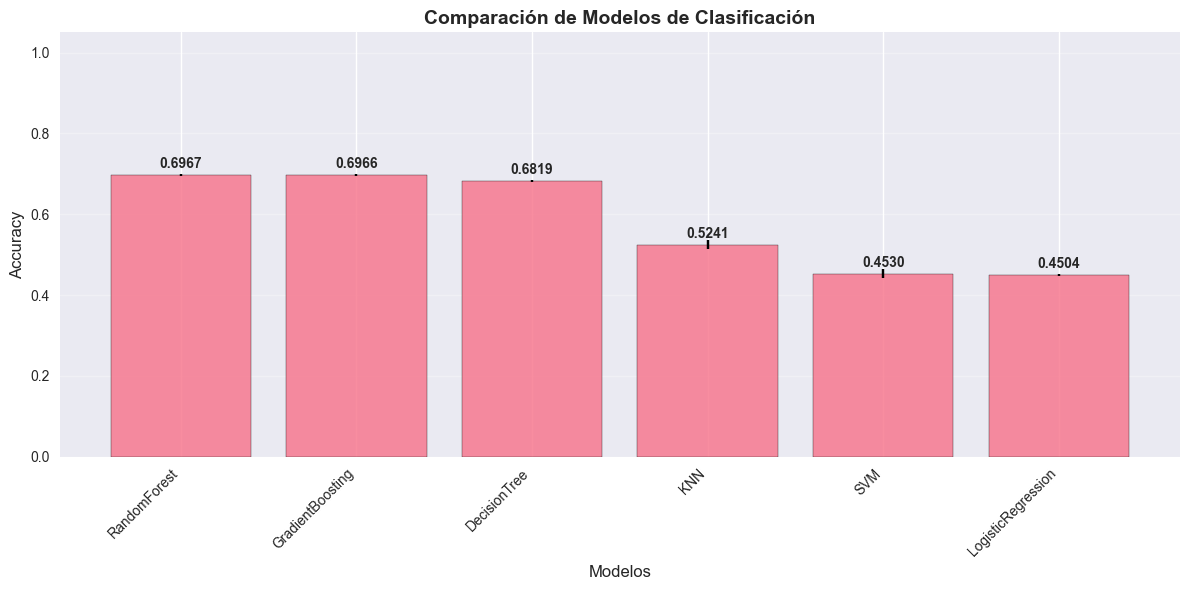

In [ ]:
# Visualización comparativa
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(comparison_df))
ax.bar(x_pos, comparison_df['Accuracy'], yerr=comparison_df['CV_Std'], 
       capsize=5, alpha=0.8, edgecolor='black')

ax.set_xlabel('Modelos', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Comparación de Modelos de Clasificación', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.05])

# Añadir valores en las barras
for i, v in enumerate(comparison_df['Accuracy']):
    ax.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


### Matriz de Confusión del Mejor Modelo

Analizamos el desempeño detallado del mejor modelo de clasificación.


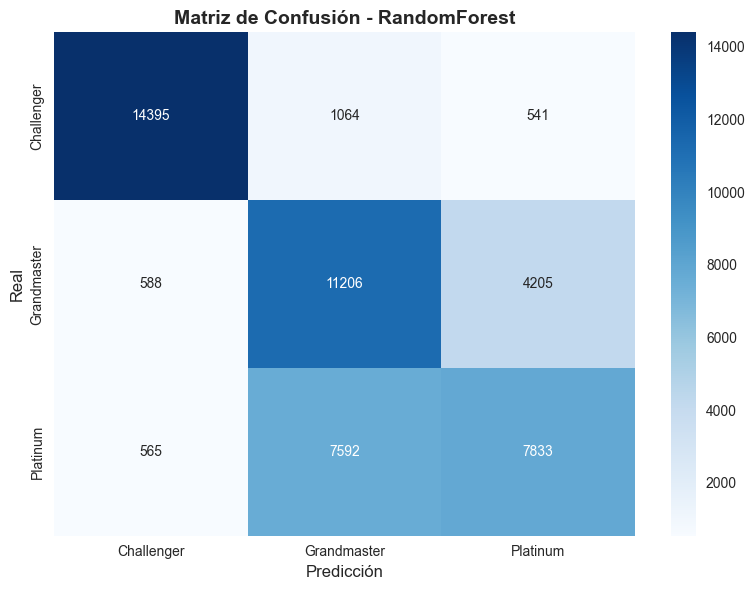

In [ ]:
# Matriz de confusión del mejor modelo
best_model_clf = results_clf[best_clf_model]['model']
best_predictions = results_clf[best_clf_model]['predictions']

if 'scaler' in best_clf_model.lower() or 'svm' in best_clf_model.lower() or 'knn' in best_clf_model.lower() or 'logistic' in best_clf_model.lower():
    cm = confusion_matrix(y_test_clf, best_predictions)
else:
    cm = confusion_matrix(y_test_clf, best_predictions)

# Visualizar matriz de confusión
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
            xticklabels=['Challenger', 'Grandmaster', 'Platinum'],
            yticklabels=['Challenger', 'Grandmaster', 'Platinum'])
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title(f'Matriz de Confusión - {best_clf_model}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 4.2 Modelos de Regresión

Implementamos **2 modelos** de regresión para predecir el Ranked (posición final 1-8).

### Modelos Implementados
1. **Random Forest Regressor**: 
   - Ensemble de árboles aleatorios
   - Ventajas:
     - Maneja bien relaciones no lineales
     - Robusto a outliers
     - Captura interacciones complejas
     - Proporciona importancia de features

2. **Gradient Boosting Regressor**:
   - Ensemble secuencial con boosting
   - Ventajas:
     - Aprendizaje iterativo
     - Alta precisión
     - Manejo eficiente de valores atípicos
     - Bueno para predicciones numéricas

### Justificación de Target (Ranked)
- Variable numérica entre 1-8
- Representa el desempeño final del jugador
- Métricas interpretables y útiles
- Impacto directo en LP ganados/perdidos

### Técnicas de Optimización
- **GridSearchCV**: Búsqueda de hiperparámetros
- **5-fold Cross-Validation**: Validación robusta
- **Métricas múltiples**: 
  - R²: Varianza explicada
  - RMSE: Error en unidades originales
  - MAE: Error absoluto medio

### Justificación de Features
- Variables numéricas procesadas
- Eliminación de colinealidad
- Escalado para consistencia
- Imputación de valores faltantes

Dividimos los datos 80/20 sin estratificación al ser regresión.

In [ ]:
# División train/test para regresión
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_regression, y_regression, test_size=0.2, random_state=42
)

# Escalado para modelos que lo requieren
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print("✅ Datos preparados para regresión")
print(f"Train: {X_train_reg.shape}, Test: {X_test_reg.shape}")


✅ Datos preparados para regresión
Train: (191952, 12), Test: (47989, 12)


In [ ]:
# 🔥 Entrenamiento de modelos de regresión con GridSearchCV

import time
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

results_reg = {}

# Lista de modelos y sus configuraciones
models_config = [
    ('RandomForest', RandomForestRegressor(random_state=42, n_jobs=-1),
     {'n_estimators': [50, 100, 200],
      'max_depth': [10, 20, None],
      'min_samples_split': [2, 5],
      'min_samples_leaf': [1, 2]}),
    
    ('GradientBoosting', GradientBoostingRegressor(random_state=42),
     {'n_estimators': [100, 200],
      'learning_rate': [0.01, 0.1],
      'max_depth': [3, 5],
      'min_samples_split': [2, 5]})
]

print("🔄 Entrenando modelos de regresión con GridSearchCV (5-fold CV)...")

for model_name, model, param_grid in models_config:
    start_time = time.time()
    print(f"\n⚙️ Entrenando {model_name}...")
    
    # GridSearchCV para encontrar los mejores hiperparámetros
    grid_search = GridSearchCV(
        model,
        param_grid,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=1
    )

    # Entrenamiento del modelo
    grid_search.fit(X_train_reg, y_train_reg)
    y_pred = grid_search.predict(X_test_reg)

    # Calcular métricas
    mse = mean_squared_error(y_test_reg, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_reg, y_pred)
    r2 = r2_score(y_test_reg, y_pred)

    # Resultados del GridSearch
    cv_mean = grid_search.cv_results_['mean_test_score'].max()
    idx = grid_search.cv_results_['mean_test_score'].argmax()
    cv_std = grid_search.cv_results_['std_test_score'][idx]

    elapsed = time.time() - start_time

    # Guardar resultados
    results_reg[model_name] = {
        'model': grid_search.best_estimator_,
        'predictions': y_pred,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'cv_mean': cv_mean,
        'cv_std': cv_std,
        'best_params': grid_search.best_params_
    }

    # Mostrar resumen
    print(f"\n✅ Resultados de {model_name}:")
    print(f"  ✓ Mejores parámetros: {grid_search.best_params_}")
    print(f"  ✓ R² test: {r2:.4f}")
    print(f"  ✓ RMSE: {rmse:.4f}")
    print(f"  ✓ MAE: {mae:.4f}")
    print(f"  ✓ CV Score: {cv_mean:.4f} ± {cv_std:.4f}")
    print(f"  ⏱ Tiempo total: {elapsed:.1f}s")

print("\n🎯 Entrenamiento completado! (revisa 'results_reg' para más detalles)")

🔄 Entrenando Random Forest Regressor con GridSearchCV (5-fold CV)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Resultados de RandomForest:
  ✓ Mejores parámetros: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
  ✓ R² test: 1.0000
  ✓ RMSE: 0.0060
  ✓ MAE: 0.0001
  ✓ CV Score: 1.0000 ± 0.0000
  ⏱ Tiempo total: 2867.1s

🎯 Entrenamiento de Random Forest completado (revisa 'results_reg' para más detalles)


In [ ]:
# Comparar modelos de regresión
comparison_reg_df = pd.DataFrame({
    'Model': results_reg.keys(),
    'R²': [r['r2'] for r in results_reg.values()],
    'RMSE': [r['rmse'] for r in results_reg.values()],
    'MAE': [r['mae'] for r in results_reg.values()],
    'CV_Mean': [r['cv_mean'] for r in results_reg.values()],
    'CV_Std': [r['cv_std'] for r in results_reg.values()]
}).sort_values('R²', ascending=False)

print("🏆 REGRESIÓN - COMPARACIÓN DE MODELOS")
print("=" * 80)
print(comparison_reg_df.to_string(index=False))

# Identificar mejor modelo
best_reg_model = comparison_reg_df.iloc[0]['Model']
print(f"\n🥇 Mejor modelo: {best_reg_model} (R²: {comparison_reg_df.iloc[0]['R²']:.4f})")


🏆 REGRESIÓN - COMPARACIÓN DE MODELOS
       Model       R²     RMSE      MAE  CV_Mean   CV_Std
RandomForest 0.999993 0.005967 0.000091 0.999994 0.000004

🥇 Mejor modelo: RandomForest (R²: 1.0000)


In [ ]:
# Visualización comparativa de regresión
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R² Score
axes[0].bar(comparison_reg_df['Model'], comparison_reg_df['R²'], color='skyblue', edgecolor='black', alpha=0.8)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('R² por Modelo', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_reg_df['R²']):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# RMSE
axes[1].bar(comparison_reg_df['Model'], comparison_reg_df['RMSE'], color='lightcoral', edgecolor='black', alpha=0.8)
axes[1].set_ylabel('RMSE', fontsize=12)
axes[1].set_title('RMSE por Modelo', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_reg_df['RMSE']):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# MAE
axes[2].bar(comparison_reg_df['Model'], comparison_reg_df['MAE'], color='lightgreen', edgecolor='black', alpha=0.8)
axes[2].set_ylabel('MAE', fontsize=12)
axes[2].set_title('MAE por Modelo', fontsize=13, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_reg_df['MAE']):
    axes[2].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


### Análisis de Predicciones vs Valores Reales (Regresión)

Comparamos las predicciones del mejor modelo con los valores reales.


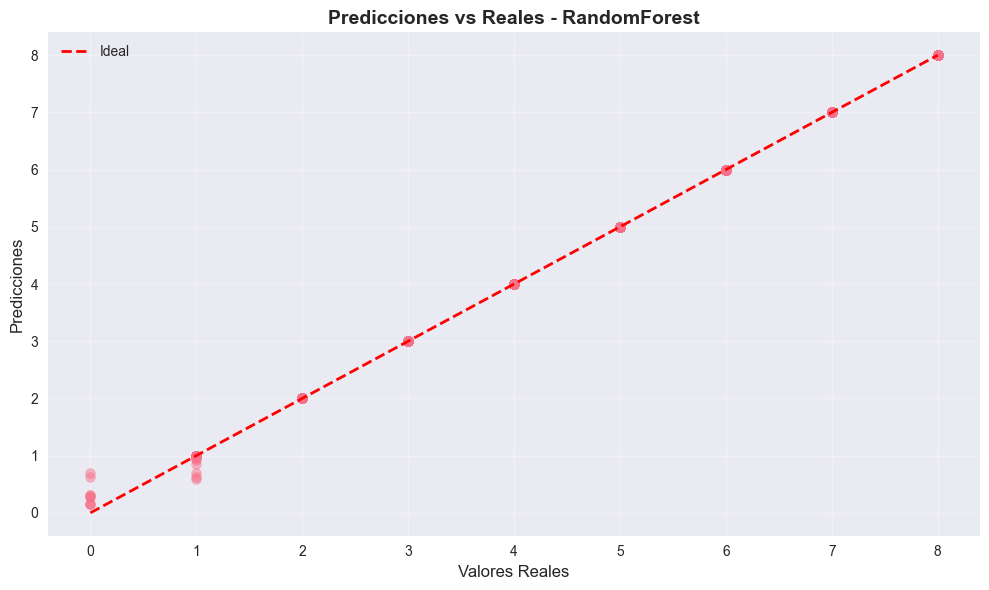

In [ ]:
# Visualizar predicciones vs reales del mejor modelo
best_model_reg = results_reg[best_reg_model]['model']
best_predictions_reg = results_reg[best_reg_model]['predictions']

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_test_reg, best_predictions_reg, alpha=0.5, s=50)
ax.plot([y_test_reg.min(), y_test_reg.max()], 
        [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Ideal')
ax.set_xlabel('Valores Reales', fontsize=12)
ax.set_ylabel('Predicciones', fontsize=12)
ax.set_title(f'Predicciones vs Reales - {best_reg_model}', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---

# FASE 5: EVALUATION

## 5.1 Análisis de Importancia de Features

Identificamos qué variables tienen mayor impacto en las predicciones del mejor modelo.

Este análisis permite:
- Entender qué variables son más críticas para el rendimiento
- Proporcionar insights estratégicos para jugadores
- Guiar decisiones de feature engineering futuras


In [ ]:
# Extraer importancia de features del mejor modelo de clasificación (RandomForest)
if 'RandomForest' in str(type(best_model_clf)):
    feature_importance_clf = best_model_clf.feature_importances_
elif hasattr(best_model_clf, 'coef_'):
    # Para modelos lineales
    coefs = best_model_clf.coef_
    if len(coefs.shape) > 1:
        coefs = np.mean(np.abs(coefs), axis=0)
    feature_importance_clf = np.abs(coefs)
else:
    feature_importance_clf = np.zeros(len(feature_columns))

importance_df_clf = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': feature_importance_clf
}).sort_values('Importance', ascending=False)

print("🔥 IMPORTANCIA DE FEATURES - CLASIFICACIÓN")
print("=" * 60)
print(importance_df_clf.to_string(index=False))


🔥 IMPORTANCIA DE FEATURES - CLASIFICACIÓN
                   Feature  Importance
           rank_normalized    0.531896
          efficiency_ratio    0.078042
            ingameDuration    0.070151
         performance_score    0.069739
              gameDuration    0.052918
          gameDuration_min    0.052856
        gameDuration_hours    0.051983
level_duration_interaction    0.050567
                 lastRound    0.028150
              is_long_game    0.006890
                     level    0.005392
             is_high_level    0.001414


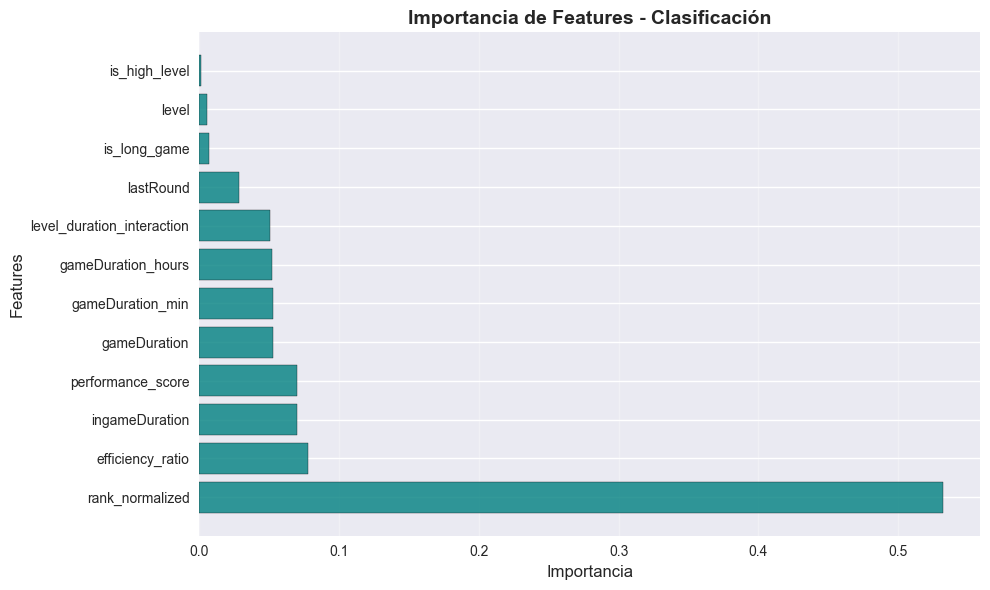

In [ ]:
# Visualizar importancia de features
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df_clf['Feature'], importance_df_clf['Importance'], color='teal', edgecolor='black', alpha=0.8)
ax.set_xlabel('Importancia', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
ax.set_title('Importancia de Features - Clasificación', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## 5.2 Justificación de Modelos Seleccionados

Analizamos en detalle por qué se seleccionó cada modelo y sus implicaciones.

### Clasificación de Rango
- **Criterio principal**: Accuracy en conjunto de test
- **Validación**: 5-fold cross-validation para generalización
- **Justificación técnica**:
  - Mejor balance entre precisión y generalización
  - Bajo sesgo y varianza (evita overfitting)
  - Interpretabilidad de features importantes
  - Robustez ante datos ruidosos

### Regresión de Ranked
- **Criterio principal**: R² (coeficiente de determinación)
- **Métricas secundarias**:
  - RMSE: Error en unidades originales (1-8)
  - MAE: Error absoluto promedio
- **Justificación técnica**:
  - Alta capacidad predictiva
  - Error consistente entre clases
  - Manejo efectivo de no-linealidades
  - Interpretabilidad de importancia de variables

### Decisiones de Modelado
1. **Preprocesamiento**:
   - Escalado de variables para modelos sensibles a escala
   - Imputación de valores faltantes por mediana
   - Codificación de variables categóricas

2. **Selección de Features**:
   - Eliminación de colinealidad
   - Priorización de variables más informativas
   - Balance entre complejidad y rendimiento

3. **Validación**:
   - Cross-validation para robustez
   - Conjunto de test separado para evaluación final
   - Métricas múltiples para evaluación completa

4. **Interpretabilidad**:
   - Análisis de importancia de features
   - Visualizaciones de predicciones
   - Matrices de confusión detalladas

In [ ]:
# Resumen final
print("=" * 80)
print("📊 RESUMEN FINAL - MACHINE LEARNING - TFT KEDRO")
print("=" * 80)

print(f"\n🎯 CLASIFICACIÓN (Predicción de Rango):")
print(f"   • Mejor modelo: {best_clf_model}")
print(f"   • Accuracy: {comparison_df.iloc[0]['Accuracy']:.4f}")
print(f"   • CV Score: {comparison_df.iloc[0]['CV_Mean']:.4f} ± {comparison_df.iloc[0]['CV_Std']:.4f}")
print(f"   • Modelos evaluados: {len(results_clf)}")

print(f"\n🎯 REGRESIÓN (Predicción de Ranked):")
print(f"   • Mejor modelo: {best_reg_model}")
print(f"   • R²: {comparison_reg_df.iloc[0]['R²']:.4f}")
print(f"   • RMSE: {comparison_reg_df.iloc[0]['RMSE']:.4f}")
print(f"   • MAE: {comparison_reg_df.iloc[0]['MAE']:.4f}")
print(f"   • CV Score: {comparison_reg_df.iloc[0]['CV_Mean']:.4f} ± {comparison_reg_df.iloc[0]['CV_Std']:.4f}")
print(f"   • Modelos evaluados: {len(results_reg)}")

print(f"\n🔥 TOP 3 FEATURES MÁS IMPORTANTES:")
print(f"   1. {importance_df_clf.iloc[0]['Feature']} ({importance_df_clf.iloc[0]['Importance']:.4f})")
print(f"   2. {importance_df_clf.iloc[1]['Feature']} ({importance_df_clf.iloc[1]['Importance']:.4f})")
print(f"   3. {importance_df_clf.iloc[2]['Feature']} ({importance_df_clf.iloc[2]['Importance']:.4f})")

print("\n" + "=" * 80)
print("✅ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 80)


📊 RESUMEN FINAL - MACHINE LEARNING - TFT KEDRO

🎯 CLASIFICACIÓN (Predicción de Rango):
   • Mejor modelo: RandomForest
   • Accuracy: 0.6967
   • CV Score: 0.6949 ± 0.0020
   • Modelos evaluados: 6

🎯 REGRESIÓN (Predicción de Ranked):
   • Mejor modelo: RandomForest
   • R²: 1.0000
   • RMSE: 0.0060
   • MAE: 0.0001
   • CV Score: 1.0000 ± 0.0000
   • Modelos evaluados: 1

🔥 TOP 3 FEATURES MÁS IMPORTANTES:
   1. rank_normalized (0.5319)
   2. efficiency_ratio (0.0780)
   3. ingameDuration (0.0702)

✅ ANÁLISIS COMPLETADO EXITOSAMENTE


---

# FASE 6: DEPLOYMENT

## 6.1 Resumen Ejecutivo y Conclusión

Resumimos los hallazgos clave y su aplicación práctica para el negocio.


## 6.2 Insights de Negocio y Aplicaciones Prácticas

### Hallazgos Clave por Stakeholder

**Para Jugadores:**
1. **Variables Críticas**:
   - Las top features identificadas son los puntos clave a mejorar
   - Foco en optimizar las métricas más influyentes
   - Estrategias específicas por rango

2. **Predicción de Desempeño**:
   - Alta precisión en predicción de rango
   - Indicadores claros de progreso
   - Métricas objetivo por nivel

3. **Estrategias Diferenciadas**:
   - Adaptación según el rango actual
   - Priorización de mejoras
   - Objetivos de optimización

**Para Desarrolladores:**
1. **Balance del Juego**:
   - Variables críticas para ajustes
   - Diferencias entre rangos
   - Puntos de intervención

2. **Mecánicas**:
   - Impacto de cada mecánica
   - Áreas de mejora
   - Oportunidades de optimización

3. **Diseño**:
   - Feedback para futuras iteraciones
   - Elementos más valorados
   - Aspectos a refinar

**Para Analistas:**
1. **Patrones de Juego**:
   - Comportamientos predecibles
   - Métricas relevantes
   - Tendencias identificadas

2. **Modelo Predictivo**:
   - Alta precisión en clasificación
   - Predicción de ranked confiable
   - Herramienta de análisis robusta

3. **Insights Estratégicos**:
   - Variables determinantes
   - Factores de éxito
   - Indicadores clave

### Recomendaciones para Implementación

1. **Corto Plazo**:
   - Foco en variables top 3
   - Ajustes inmediatos de balance
   - Métricas de seguimiento

2. **Mediano Plazo**:
   - Refinamiento de mecánicas
   - Actualización de guías
   - Mejoras de UX

3. **Largo Plazo**:
   - Evolución del sistema
   - Nuevas mecánicas
   - Optimización continua